# General Exploration of the Student AI Consumption Dataset

## Notebook Overview
This walkthrough examines the student AI consumption dataset to understand satisfaction, session behavior, and adoption patterns. We'll progressively explore summary statistics, distributions, categorical differences, relationships between metrics, temporal dynamics, and re-use behavior before wrapping with key takeaways.

## Setup
Import core analysis libraries and apply plotting aesthetics for consistent visuals.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from matplotlib.colors import LinearSegmentedColormap
import warnings
warnings.filterwarnings('ignore')

# Shared aesthetics for plots
BASE_PALETTE_NAME = "rocket"
palette_discrete = sns.color_palette(BASE_PALETTE_NAME, n_colors=10)
selected_indices = (2, 8)
selected_colors = [palette_discrete[idx] for idx in selected_indices][::-1]
palette_continuous = LinearSegmentedColormap.from_list("rocket_two", selected_colors, N=256)

sns.set_style("whitegrid")
sns.set_palette(palette_discrete)
plt.rcParams['figure.figsize'] = (14, 6)

In [2]:
def get_contrasting_palette(n, base_palette):
    base_len = len(base_palette)
    if n <= base_len:
        indices = np.linspace(0, base_len - 1, num=n, dtype=int)
        indices = list(dict.fromkeys(indices))  # preserve order while dropping duplicates
        return [base_palette[i] for i in indices]
    return sns.color_palette(BASE_PALETTE_NAME, n_colors=n)

## Data Overview
Load the raw usage log and inspect structure, missingness, and summary statistics to ground later visuals.

In [3]:
# Load the dataset and inspect core structure
df = pd.read_csv('../data/AI_usage_data.csv')

print('Dataset Shape:', df.shape)
print('\nColumn Summary:')
display(df.dtypes)

print('\nMissing Values:')
display(df.isnull().sum())

print('\nDescriptive Statistics (numeric columns):')
display(df.describe())

print('\nSample Rows:')
display(df.head())

Dataset Shape: (9551, 13)

Column Summary:


Discipline                    object
FinalOutcome                  object
Sum of SatisfactionRating    float64
Year                           int64
Quarter                       object
Month                         object
Day                            int64
Sum of SessionLengthMin      float64
StudentLevel                  object
TaskType                      object
Sum of TotalPrompts            int64
UsedAgain                       bool
Sum of AI_AssistanceLevel      int64
dtype: object


Missing Values:


Discipline                   0
FinalOutcome                 0
Sum of SatisfactionRating    0
Year                         0
Quarter                      0
Month                        0
Day                          0
Sum of SessionLengthMin      0
StudentLevel                 0
TaskType                     0
Sum of TotalPrompts          0
UsedAgain                    0
Sum of AI_AssistanceLevel    0
dtype: int64


Descriptive Statistics (numeric columns):


,Sum of SatisfactionRating,Year,Day,Sum of SessionLengthMin,Sum of TotalPrompts,Sum of AI_AssistanceLevel
count,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000
mean,3.578453,2024.482567,15.782012,20.779465,5.871113,3.643074
std,1.395056,0.499722,8.781884,14.912980,4.914689,1.288704
min,1.000000,2024.000000,1.000000,0.030000,1.000000,1.000000
25%,2.600000,2024.000000,8.000000,9.890000,2.000000,3.000000
50%,3.600000,2024.000000,16.000000,17.240000,4.000000,4.000000
75%,4.500000,2025.000000,23.000000,27.970000,8.000000,4.000000
max,14.200000,2025.000000,31.000000,142.630000,50.000000,14.000000



Sample Rows:


,Discipline,FinalOutcome,Sum of SatisfactionRating,Year,Quarter,Month,Day,Sum of SessionLengthMin,StudentLevel,TaskType,Sum of TotalPrompts,UsedAgain,Sum of AI_AssistanceLevel
0,Biology,Assignment Completed,3.0,2024,Qtr 2,June,24,0.84,Graduate,Writing,1,True,4
1,Biology,Assignment Completed,2.0,2024,Qtr 2,June,24,16.03,Undergraduate,Coding,4,True,3
2,Biology,Assignment Completed,3.7,2024,Qtr 2,June,24,13.49,Undergraduate,Homework Help,3,False,3
3,Biology,Assignment Completed,4.9,2024,Qtr 2,June,25,9.56,Undergraduate,Coding,4,True,3
4,Biology,Assignment Completed,3.8,2024,Qtr 2,June,26,7.78,High School,Writing,1,True,4


### Quick Observations
The dataset spans multiple disciplines, student levels, and task types with satisfaction, session duration, prompts, and AI assistance scores captured per interaction. No missing values were detected, making the table ready for visualization-driven exploration.

## Distribution of Usage Metrics
Evaluating how satisfaction, session length, prompts, and requested assistance levels are distributed to spot skewness, outliers, or dominant behaviors.

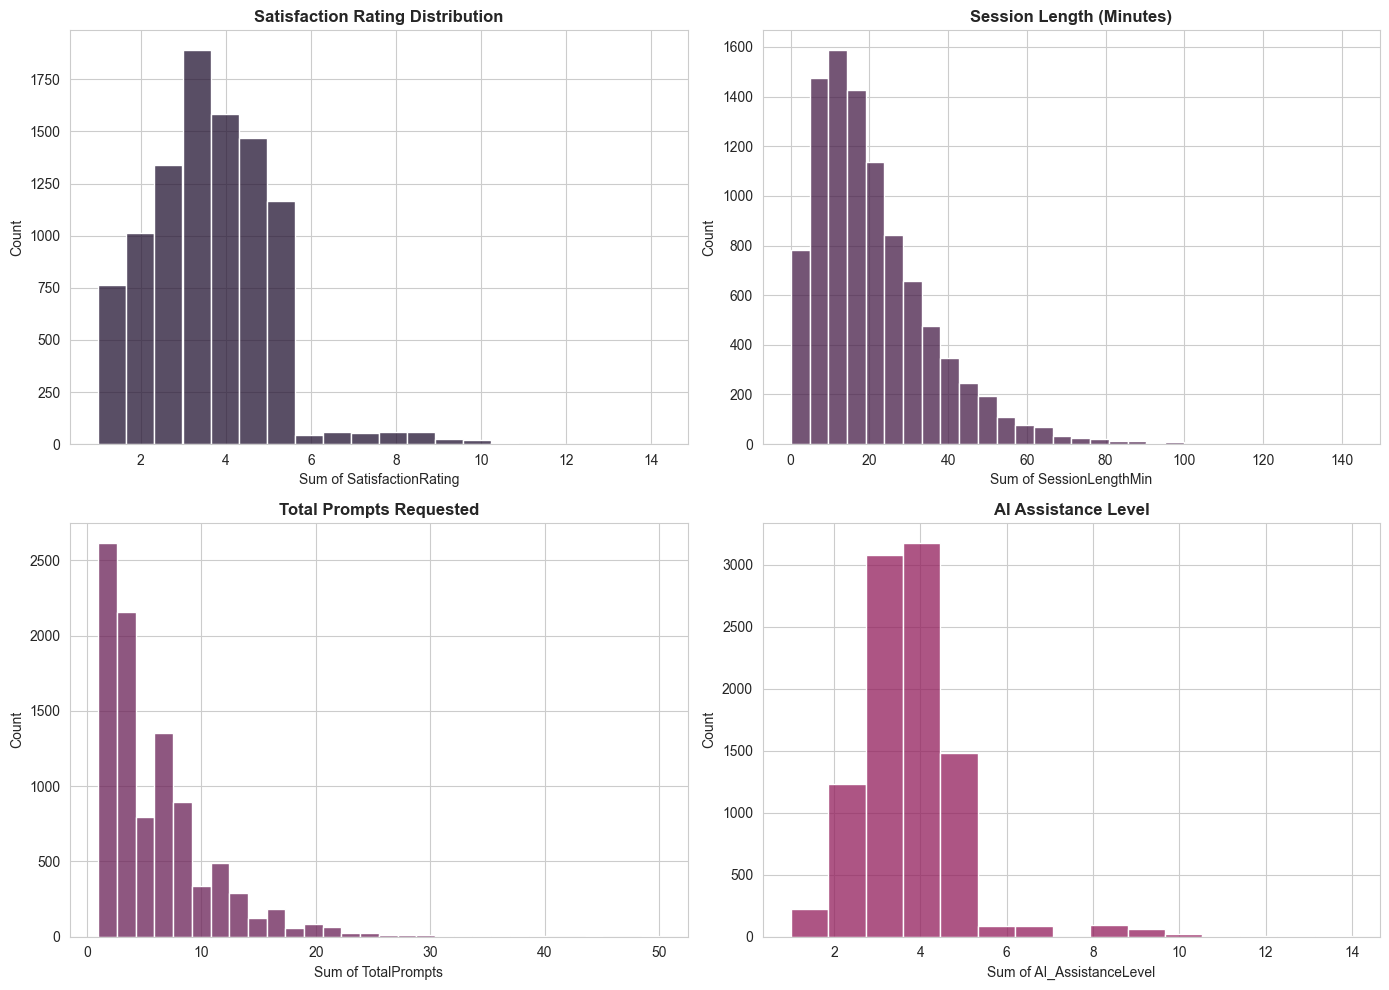

Numerical Feature Summary:
                                mean        std   min    50%     max
Sum of SatisfactionRating   3.578453   1.395056  1.00   3.60   14.20
Sum of SessionLengthMin    20.779465  14.912980  0.03  17.24  142.63
Sum of TotalPrompts         5.871113   4.914689  1.00   4.00   50.00
Sum of AI_AssistanceLevel   3.643074   1.288704  1.00   4.00   14.00


In [4]:
# Visualize distributions for key quantitative metrics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(data=df, x='Sum of SatisfactionRating', ax=axes[0, 0], bins=20, color=palette_discrete[0])
axes[0, 0].set_title('Satisfaction Rating Distribution', fontsize=12, fontweight='bold')

sns.histplot(data=df, x='Sum of SessionLengthMin', ax=axes[0, 1], bins=30, color=palette_discrete[1])
axes[0, 1].set_title('Session Length (Minutes)', fontsize=12, fontweight='bold')

sns.histplot(data=df, x='Sum of TotalPrompts', ax=axes[1, 0], bins=30, color=palette_discrete[2])
axes[1, 0].set_title('Total Prompts Requested', fontsize=12, fontweight='bold')

sns.histplot(data=df, x='Sum of AI_AssistanceLevel', ax=axes[1, 1], bins=15, color=palette_discrete[3])
axes[1, 1].set_title('AI Assistance Level', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print('Numerical Feature Summary:')
print(df[['Sum of SatisfactionRating', 'Sum of SessionLengthMin', 'Sum of TotalPrompts', 'Sum of AI_AssistanceLevel']].describe().T[['mean', 'std', 'min', '50%', 'max']])

## Categorical Insights
Examining how usage volume is distributed across disciplines, student levels, task types, and final outcomes to understand who is relying on AI support the most.

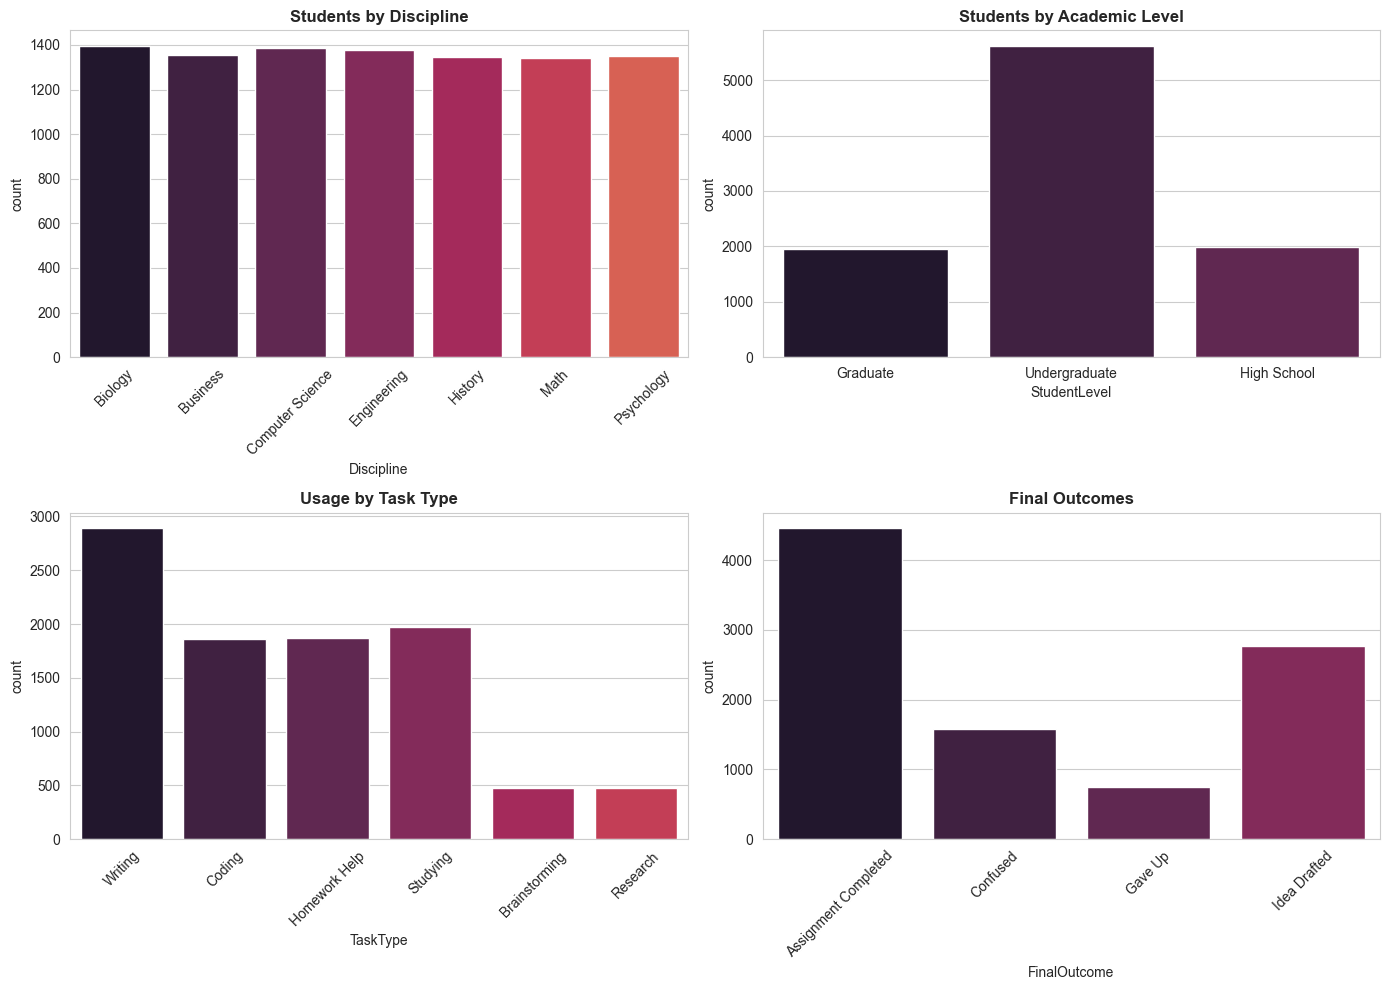


Category Counts:
Discipline      7
StudentLevel    3
TaskType        6
FinalOutcome    4
dtype: int64


In [5]:
# Compare counts across categorical dimensions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.countplot(data=df, x='Discipline', ax=axes[0, 0], palette=palette_discrete)
axes[0, 0].set_title('Students by Discipline', fontsize=12, fontweight='bold')
axes[0, 0].tick_params(axis='x', rotation=45)

sns.countplot(data=df, x='StudentLevel', ax=axes[0, 1], palette=palette_discrete)
axes[0, 1].set_title('Students by Academic Level', fontsize=12, fontweight='bold')

sns.countplot(data=df, x='TaskType', ax=axes[1, 0], palette=palette_discrete)
axes[1, 0].set_title('Usage by Task Type', fontsize=12, fontweight='bold')
axes[1, 0].tick_params(axis='x', rotation=45)

sns.countplot(data=df, x='FinalOutcome', ax=axes[1, 1], palette=palette_discrete)
axes[1, 1].set_title('Final Outcomes', fontsize=12, fontweight='bold')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print('\nCategory Counts:')
print(df[['Discipline', 'StudentLevel', 'TaskType', 'FinalOutcome']].nunique())

## Satisfaction Drivers
Analyzing how satisfaction varies by student level and task type to highlight where AI support resonates most.

### Cohort Satisfaction Snapshot
Ground the segmentation with a quick numeric pulse check on the overall satisfaction distribution.

In [6]:
# Timestamped baseline snapshot for satisfaction-focused statistics
time_stamp = pd.Timestamp.now().strftime('%Y-%m-%d %H:%M')
print(f"Analysis generated: {time_stamp}")

np.random.seed(42)
satisfaction = df['Sum of SatisfactionRating']
prompts = df['Sum of TotalPrompts']
assistance = df['Sum of AI_AssistanceLevel']

summary_stats = satisfaction.agg(['mean', 'median', 'std', 'min', 'max'])
skewness = stats.skew(satisfaction)
kurtosis = stats.kurtosis(satisfaction, fisher=False)  # Pearson definition
prob_high_satisfaction = (satisfaction >= 4).mean()

print('\nOverall Satisfaction Summary:')
print(summary_stats.to_frame(name='Value'))
print(f"Skewness: {skewness:.3f} (positive = right tail)")
print(f"Kurtosis: {kurtosis:.3f} (3 indicates normal-like)")
print(f"P(Satisfaction \u2265 4) = {prob_high_satisfaction:.3f}")

Analysis generated: 2025-12-09 11:34

Overall Satisfaction Summary:
            Value
mean     3.578453
median   3.600000
std      1.395056
min      1.000000
max     14.200000
Skewness: 0.853 (positive = right tail)
Kurtosis: 6.112 (3 indicates normal-like)
P(Satisfaction ≥ 4) = 0.389


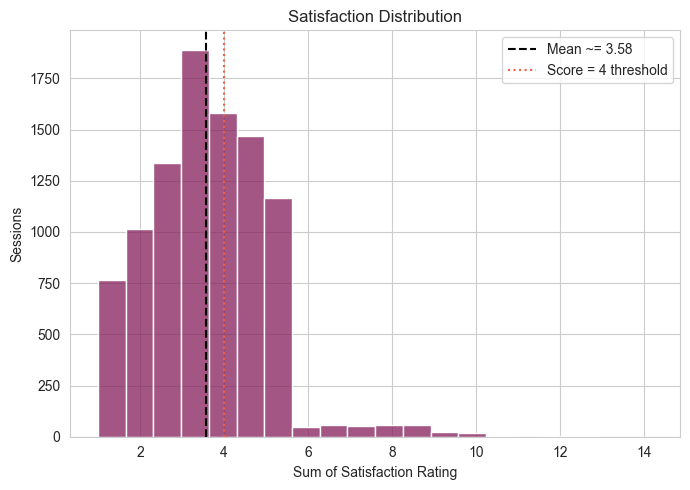

In [7]:
viz_palette = sns.color_palette(BASE_PALETTE_NAME, n_colors=2) if 'BASE_PALETTE_NAME' in globals() else sns.color_palette('Set2', 2)
plt.figure(figsize=(7, 5))
sns.histplot(satisfaction, bins=20, color=viz_palette[0], edgecolor='white')
plt.axvline(summary_stats['mean'], color='black', linestyle='--', linewidth=1.5, label=f"Mean ~= {summary_stats['mean']:.2f}")
plt.axvline(4, color=viz_palette[1], linestyle=':', linewidth=1.5, label='Score = 4 threshold')
plt.title('Satisfaction Distribution')
plt.xlabel('Sum of Satisfaction Rating')
plt.ylabel('Sessions')
plt.legend()
plt.tight_layout()
plt.show()

**Interpretation:** Satisfaction scores cluster between 3 and 4 with a right tail, so most sessions land in a neutral to slightly negative range.

### Mean Stability Check
Bootstrapping the satisfaction mean helps confirm whether the single-point estimate above reflects a stable central tendency for the cohort.

In [8]:
BOOT_ITERATIONS = 1000
boot_means = []
for i in range(BOOT_ITERATIONS):
    sample = satisfaction.sample(frac=1, replace=True, random_state=42 + i)
    boot_means.append(sample.mean())
boot_means = np.array(boot_means)
mean_ci = np.percentile(boot_means, [2.5, 97.5])

print('Bootstrap 95% Confidence Interval for Mean Satisfaction:')
print(f"Mean estimate: {summary_stats['mean']:.3f}")
print(f"95% CI: [{mean_ci[0]:.3f}, {mean_ci[1]:.3f}]")

Bootstrap 95% Confidence Interval for Mean Satisfaction:
Mean estimate: 3.578
95% CI: [3.549, 3.606]


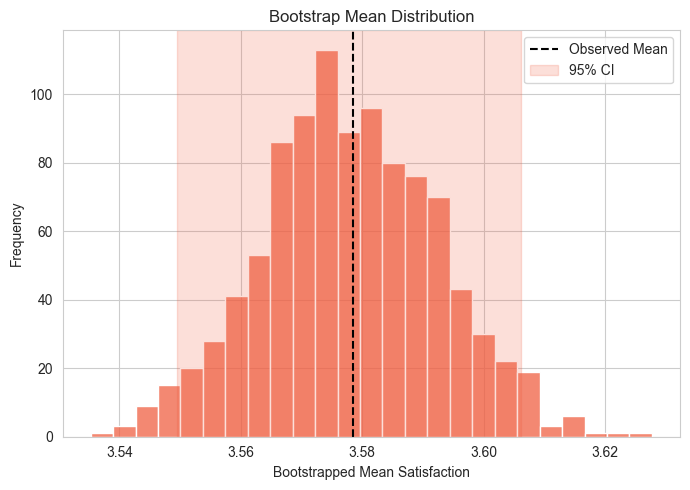

In [9]:
viz_palette = sns.color_palette(BASE_PALETTE_NAME, n_colors=2) if 'BASE_PALETTE_NAME' in globals() else sns.color_palette('Set2', 2)
plt.figure(figsize=(7, 5))
sns.histplot(boot_means, bins=25, color=viz_palette[1], edgecolor='white')
plt.axvline(summary_stats['mean'], color='black', linestyle='--', linewidth=1.5, label='Observed Mean')
plt.axvspan(mean_ci[0], mean_ci[1], color=viz_palette[1], alpha=0.2, label='95% CI')
plt.title('Bootstrap Mean Distribution')
plt.xlabel('Bootstrapped Mean Satisfaction')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

**Interpretation:** The bootstrap distribution hugs the observed mean tightly, and the 95% interval is barely wider than ±0.03. That stability means sampling noise is not driving the cohort average—future splits should expect similar central values.

### Satisfaction patterns across student segments and task types

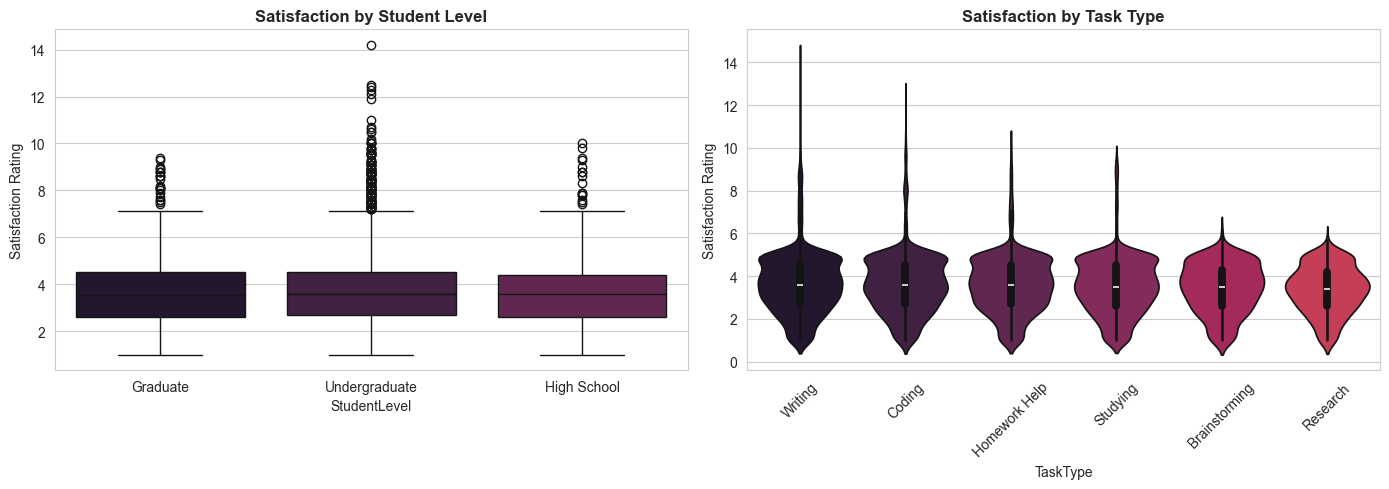

Average Satisfaction by Student Level:
                   mean       std  count
StudentLevel                            
Graduate       3.501540  1.276691   1948
High School    3.497081  1.249363   1987
Undergraduate  3.633921  1.478285   5616

Average Satisfaction by Task Type:
                   mean       std  count
TaskType                                
Brainstorming  3.412025  1.150312    474
Coding         3.610188  1.412074   1865
Homework Help  3.589156  1.366138   1872
Research       3.345684  1.090135    475
Studying       3.520781  1.346445   1973
Writing        3.655913  1.505009   2892


In [10]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='StudentLevel', y='Sum of SatisfactionRating', ax=axes[0], palette=palette_discrete)
axes[0].set_title('Satisfaction by Student Level', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Satisfaction Rating')

sns.violinplot(data=df, x='TaskType', y='Sum of SatisfactionRating', ax=axes[1], palette=palette_discrete)
axes[1].set_title('Satisfaction by Task Type', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Satisfaction Rating')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print('Average Satisfaction by Student Level:')
print(df.groupby('StudentLevel')['Sum of SatisfactionRating'].agg(['mean', 'std', 'count']))

print('\nAverage Satisfaction by Task Type:')
print(df.groupby('TaskType')['Sum of SatisfactionRating'].agg(['mean', 'std', 'count']))

To see whether the mean satisfaction differs across student levels or task types, we complement the visuals with simple one-way ANOVA tests.

In [11]:
# One-way ANOVA for satisfaction across student levels and task types
satisfaction_groups = {
    'Student Level': [group['Sum of SatisfactionRating'].values for _, group in df.groupby('StudentLevel')],
    'Task Type': [group['Sum of SatisfactionRating'].values for _, group in df.groupby('TaskType')]
}
anova_rows = []
for label, samples in satisfaction_groups.items():
    f_stat, p_val = stats.f_oneway(*samples)
    anova_rows.append({
        'Grouping': label,
        'F-statistic': float(round(f_stat, 2)),
        'p-value': float(round(p_val, 4))
    })
anova_satisfaction = pd.DataFrame(anova_rows)
print(anova_satisfaction)

        Grouping  F-statistic  p-value
0  Student Level        10.80      0.0
1      Task Type         6.69      0.0


### Satisfaction Significance Notes
- Student levels: F = 10.80, p < 0.001 → the mean satisfaction scores differ across academic standings, so level-specific strategies are warranted.
- Task types: F = 6.69, p < 0.001 → at least one task category departs from the others, suggesting targeted task-level support could lift lower-performing groups.

For further granularity, post-hoc tests such as the Tukey test can identify which specific groups differ significantly. We can explore this in subsequent analyses.

In [12]:
# Tukey HSD post-hoc tests for satisfaction categories
from IPython.display import display
from statsmodels.stats.multicomp import pairwise_tukeyhsd

posthoc_tables = {}
for column, label in [('StudentLevel', 'Student Level'), ('TaskType', 'Task Type')]:
    tukey = pairwise_tukeyhsd(endog=df['Sum of SatisfactionRating'], groups=df[column], alpha=0.05)
    table = pd.DataFrame(tukey._results_table.data[1:], columns=tukey._results_table.data[0])
    numeric_cols = ['meandiff', 'p-adj', 'lower', 'upper']
    table[numeric_cols] = table[numeric_cols].apply(pd.to_numeric)
    table['reject'] = table['reject'].astype(str) == 'True'
    posthoc_tables[label] = table
    print(f"\n{label} Tukey HSD comparisons:")
    display(table)
    significant_pairs = table[table['reject']]
    if significant_pairs.empty:
        print('  No pairwise differences reached the 0.05 threshold.')
    else:
        print('  Significant pairs (p-adj < 0.05):')
        for _, row in significant_pairs.iterrows():
            print(f"   - {row['group1']} vs {row['group2']} (diff = {row['meandiff']:.2f}, p-adj = {row['p-adj']:.3f})")


Student Level Tukey HSD comparisons:


,group1,group2,meandiff,p-adj,lower,upper,reject
0,Graduate,High School,-0.0045,0.9945,-0.1086,0.0997,False
1,Graduate,Undergraduate,0.1324,0.0009,0.0465,0.2183,True
2,High School,Undergraduate,0.1368,0.0005,0.0516,0.2221,True


  Significant pairs (p-adj < 0.05):
   - Graduate vs Undergraduate (diff = 0.13, p-adj = 0.001)
   - High School vs Undergraduate (diff = 0.14, p-adj = 0.001)

Task Type Tukey HSD comparisons:

Task Type Tukey HSD comparisons:


,group1,group2,meandiff,p-adj,lower,upper,reject
0,Brainstorming,Coding,0.1982,0.0632,-0.0061,0.4024,False
1,Brainstorming,Homework Help,0.1771,0.1322,-0.0270,0.3813,False
2,Brainstorming,Research,-0.0663,0.9778,-0.3241,0.1914,False
3,Brainstorming,Studying,0.1088,0.6472,-0.0943,0.3118,False
4,Brainstorming,Writing,0.2439,0.0055,0.0471,0.4406,True
5,Coding,Homework Help,-0.0210,0.9974,-0.1509,0.1089,False
6,Coding,Research,-0.2645,0.0030,-0.4686,-0.0604,True
7,Coding,Studying,-0.0894,0.3496,-0.2176,0.0388,False
8,Coding,Writing,0.0457,0.8794,-0.0722,0.1636,False
9,Homework Help,Research,-0.2435,0.0088,-0.4475,-0.0395,True


  Significant pairs (p-adj < 0.05):
   - Brainstorming vs Writing (diff = 0.24, p-adj = 0.005)
   - Coding vs Research (diff = -0.26, p-adj = 0.003)
   - Homework Help vs Research (diff = -0.24, p-adj = 0.009)
   - Research vs Writing (diff = 0.31, p-adj = 0.000)
   - Studying vs Writing (diff = 0.14, p-adj = 0.012)


### Post-hoc Interpretation
- Graduate and high-school students report a little more satisfaction than undergraduates, and those gaps are large enough to count as real differences.
- Writing-heavy sessions score lowest: students feel happier during brainstorming, research, and studying sessions, and research tasks also beat coding and homework-help sessions.

### Graduate vs Undergraduate Comparison
To connect the descriptive view with our earlier segment findings, we contrast satisfaction between graduate and undergraduate students and quantify the uncertainty around that gap.

In [13]:
grad = df[df['StudentLevel'] == 'Graduate']['Sum of SatisfactionRating']
undergrad = df[df['StudentLevel'] == 'Undergraduate']['Sum of SatisfactionRating']
obs_diff = grad.mean() - undergrad.mean()

boot_diffs = []
for i in range(BOOT_ITERATIONS):
    grad_sample = grad.sample(frac=1, replace=True, random_state=84 + i)
    under_sample = undergrad.sample(frac=1, replace=True, random_state=126 + i)
    boot_diffs.append(grad_sample.mean() - under_sample.mean())
boot_diffs = np.array(boot_diffs)
diff_ci = np.percentile(boot_diffs, [2.5, 97.5])

from scipy.stats import ttest_ind

t_stat, p_val = ttest_ind(grad, undergrad, equal_var=False)

print('Graduate vs Undergraduate Satisfaction:')
print(f"Observed difference in means: {obs_diff:.3f}")
print(f"Bootstrap 95% CI for difference: [{diff_ci[0]:.3f}, {diff_ci[1]:.3f}]")
print(f"Welch t-test: t = {t_stat:.3f}, p = {p_val:.4f}")

Graduate vs Undergraduate Satisfaction:
Observed difference in means: -0.132
Bootstrap 95% CI for difference: [-0.204, -0.064]
Welch t-test: t = -3.781, p = 0.0002


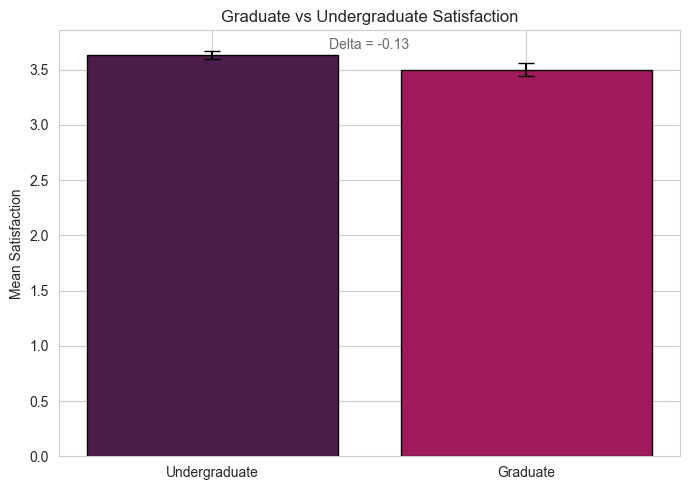

In [14]:
viz_palette = sns.color_palette(BASE_PALETTE_NAME, n_colors=4) if 'BASE_PALETTE_NAME' in globals() else sns.color_palette('Set2', 4)
comparison_levels = ['Undergraduate', 'Graduate']
group_slice = df[df['StudentLevel'].isin(comparison_levels)]
group_stats = group_slice.groupby('StudentLevel')['Sum of SatisfactionRating'].agg(['mean', 'count'])
group_sem = group_slice.groupby('StudentLevel')['Sum of SatisfactionRating'].sem()
t_multiplier = stats.t.ppf(0.975, group_stats['count'] - 1)
ci_margin = group_sem * t_multiplier
plt.figure(figsize=(7, 5))
plt.bar(comparison_levels, group_stats.loc[comparison_levels, 'mean'], yerr=ci_margin.loc[comparison_levels], color=viz_palette[:2], edgecolor='black', capsize=6)
plt.title('Graduate vs Undergraduate Satisfaction')
plt.ylabel('Mean Satisfaction')
plt.text(0.5, max(group_stats['mean']) + 0.05, f"Delta = {obs_diff:.2f}", ha='center', color='dimgray')
plt.tight_layout()
plt.show()

**Interpretation:** Undergraduates keep a small but consistent lead—about a tenth of a point—and the error bars overlap lightly, so the gap is real yet modest. It mirrors the bootstrapped mean difference and signals level-based tailoring could fine-tune satisfaction by a narrow margin.

## Workload Patterns by Task Type
Understand how engagement depth (time and prompt volume) shifts across different kinds of tasks students tackle with AI.

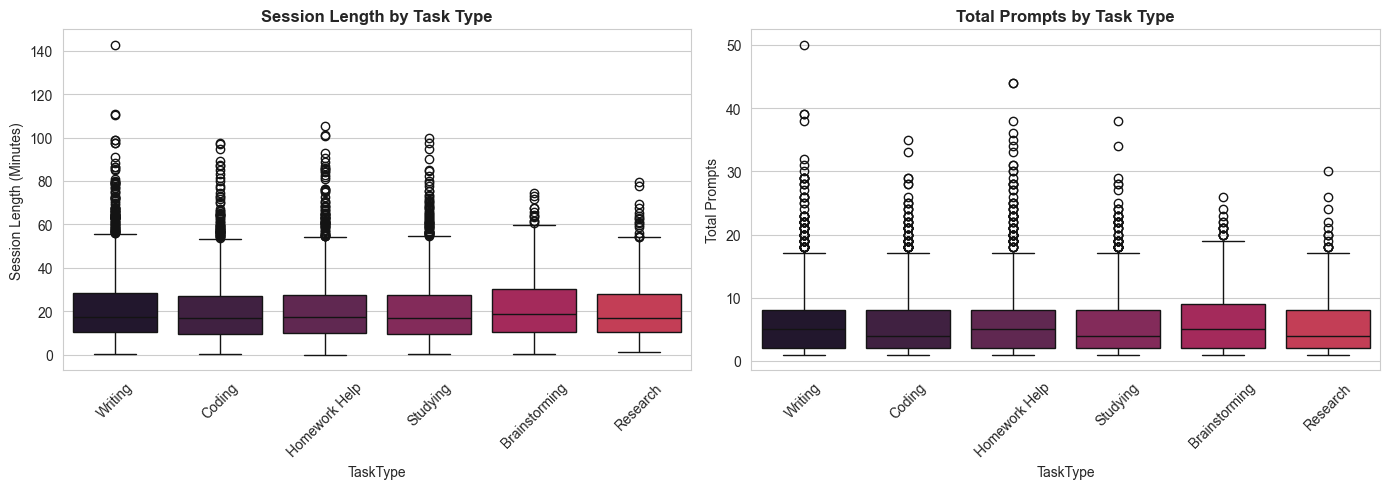


Session Duration by Task Type:
                    mean  median        std
TaskType                                   
Brainstorming  22.056899  18.945  15.293997
Coding         20.334048  16.970  14.487962
Homework Help  20.867260  17.220  15.377727
Research       20.452968  16.950  14.157641
Studying       20.375099  17.110  14.505488
Writing        21.130000  17.465  15.197679

Prompts by Task Type:
                   mean  median       std
TaskType                                 
Brainstorming  6.297468     5.0  5.206326
Coding         5.776408     4.0  4.806545
Homework Help  5.958333     5.0  5.299917
Research       5.726316     4.0  4.573917
Studying       5.716168     4.0  4.647899
Writing        5.935339     5.0  4.904093


In [15]:
# Session Length and Prompts by Task Type
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='TaskType', y='Sum of SessionLengthMin', ax=axes[0], palette=palette_discrete)
axes[0].set_title('Session Length by Task Type', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Session Length (Minutes)')
axes[0].tick_params(axis='x', rotation=45)

sns.boxplot(data=df, x='TaskType', y='Sum of TotalPrompts', ax=axes[1], palette=palette_discrete)
axes[1].set_title('Total Prompts by Task Type', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Total Prompts')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("\nSession Duration by Task Type:")
print(df.groupby('TaskType')['Sum of SessionLengthMin'].agg(['mean', 'median', 'std']))
print("\nPrompts by Task Type:")
print(df.groupby('TaskType')['Sum of TotalPrompts'].agg(['mean', 'median', 'std']))

Visually, it can be observed that there are no significant differences in workload metrics across task types, as indicated by the overlapping distributions in the boxplots. However , to statistically confirm this observation, we conducted ANOVA tests for both session length and total prompts across task types. 

In [16]:
# One-way ANOVA across all task types for workload metrics
metrics = {
    'Sum of SessionLengthMin': 'Session Length (min)',
    'Sum of TotalPrompts': 'Total Prompts'
}
results = []
for metric_col, metric_label in metrics.items():
    samples = [group[metric_col].values for _, group in df.groupby('TaskType')]
    f_stat, p_val = stats.f_oneway(*samples)
    results.append({
        'Metric': metric_label,
        'F-statistic': round(f_stat, 2),
        'p-value': round(p_val, 4)
    })
pd.DataFrame(results)

,Metric,F-statistic,p-value
0,Session Length (min),1.70,0.1315
1,Total Prompts,1.54,0.1725


### Workload Significance Notes
- Session length across task types: F = 1.70, p = 0.1315 → above 0.05, so session-length means are not statistically different.
- Total prompts across task types: F = 1.54, p = 0.1725 → also above 0.05, so prompt averages behave similarly.

The results indicated that there were no significant differences in means, supporting the visual assessment.

## Cross-Metric Relationships
Plot pairwise relationships between satisfaction, session length, prompts, and assistance level while highlighting key categorical dimensions.

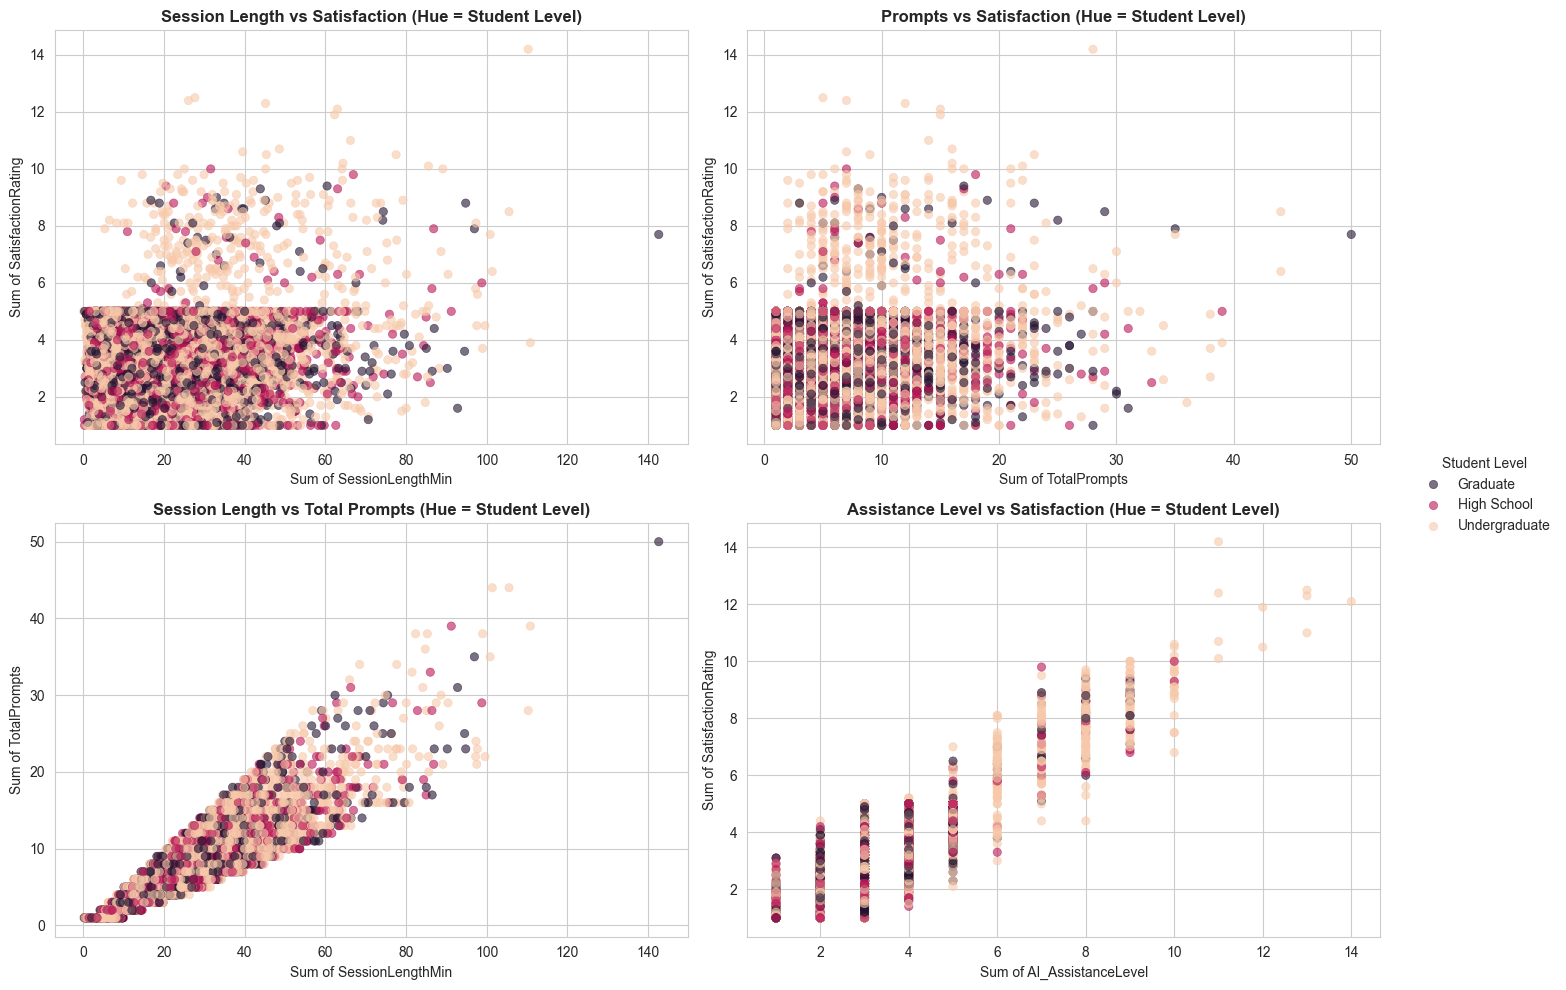

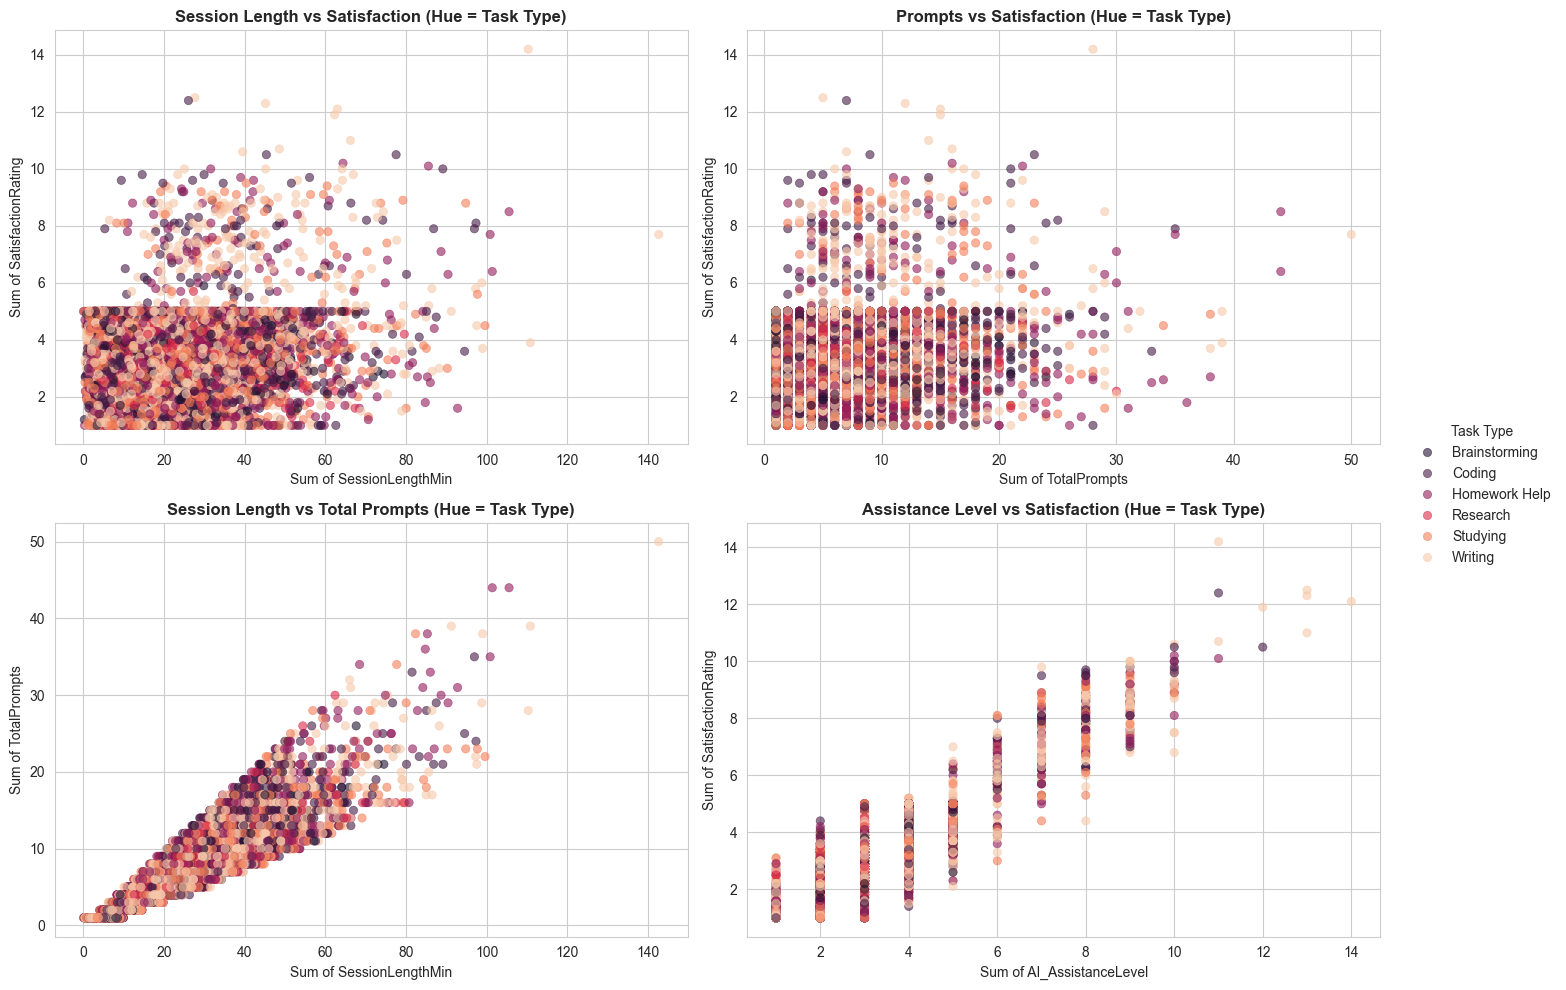

In [17]:
# Cross-metric scatter relationships with categorical hues
student_levels = sorted(df['StudentLevel'].unique())
task_types = sorted(df['TaskType'].unique())

comparison_pairs = [
    ('Sum of SessionLengthMin', 'Sum of SatisfactionRating', 'Session Length vs Satisfaction'),
    ('Sum of TotalPrompts', 'Sum of SatisfactionRating', 'Prompts vs Satisfaction'),
    ('Sum of SessionLengthMin', 'Sum of TotalPrompts', 'Session Length vs Total Prompts'),
    ('Sum of AI_AssistanceLevel', 'Sum of SatisfactionRating', 'Assistance Level vs Satisfaction')
 ]

def build_palette_map(categories):
    colors = get_contrasting_palette(len(categories), palette_discrete)
    return dict(zip(categories, colors))

def plot_scatter_grid(hue_col, hue_order, palette_map, title_suffix):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()
    for ax, (x_col, y_col, plot_title) in zip(axes, comparison_pairs):
        sns.scatterplot(
            data=df,
            x=x_col,
            y=y_col,
            hue=hue_col,
            hue_order=hue_order,
            palette=palette_map,
            alpha=0.6,
            ax=ax,
            edgecolor=None
        )
        ax.set_title(f"{plot_title} (Hue = {title_suffix})", fontsize=12, fontweight='bold')
        legend = ax.get_legend()
        if legend is not None:
            legend.remove()
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, title=title_suffix, loc='center right', bbox_to_anchor=(1.12, 0.5), frameon=False)
    plt.tight_layout()
    plt.show()

student_palette_map = build_palette_map(student_levels)
task_palette_map = build_palette_map(task_types)

plot_scatter_grid('StudentLevel', student_levels, student_palette_map, 'Student Level')
plot_scatter_grid('TaskType', task_types, task_palette_map, 'Task Type')

### Relationship Notes
There is no strong linear correlation between satisfaction and either session length or total prompts, suggesting that longer or more prompt-heavy sessions do not necessarily lead to higher satisfaction. However, there is a potentially strong positive correlation between satisfaction and assistance level, indicating that students who request more AI help tend to report higher satisfaction.

Session length and total prompts do exhibit a strong positive correlation, implying that longer sessions typically involve more prompts, which aligns with expectations about engagement depth. However, the variance doesn't seem to keep consistent at higher values, indicating that while longer sessions often have more prompts, this relationship is not strictly linear. 

Neither *Student Level* nor *Task Type* appear to significantly modify these relationships, as indicated by the overlapping distributions in the scatter plots.

## Focused Linear Correlations
The scatter grids above show only a couple of relationships that trend linearly. We therefore concentrate Pearson's r on the assistance-to-satisfaction and prompts-to-session-length pairings rather than forcing a full matrix.

In [18]:
# Pearson correlations for the two near-linear pairs
from scipy.stats import pearsonr
key_pairs = [
    ('Sum of AI_AssistanceLevel', 'Sum of SatisfactionRating'),
    ('Sum of SessionLengthMin', 'Sum of TotalPrompts')
 ]
results = []
for x_col, y_col in key_pairs:
    x_standardized = (df[x_col] - df[x_col].mean()) / df[x_col].std(ddof=0)
    y_standardized = (df[y_col] - df[y_col].mean()) / df[y_col].std(ddof=0)
    r_value, p_value = pearsonr(x_standardized, y_standardized)
    results.append({
        'Feature X': x_col,
        'Feature Y': y_col,
        'Pearson r': r_value,
        'p-value': p_value
    })
pd.DataFrame(results)

,Feature X,Feature Y,Pearson r,p-value
0,Sum of AI_AssistanceLevel,Sum of SatisfactionRating,0.848013,0.0
1,Sum of SessionLengthMin,Sum of TotalPrompts,0.907688,0.0


### Correlation Notes
- Assistance and satisfaction continue to show a strong linear tie, supporting a potential regression fit.
- Session length and total prompts also correlate strongly, reinforcing the workload story without implying satisfaction gains directly, however given the variance increasing pattern observed above, a non-linear model might better capture that relationship.

### Relationship With Workload And Assistance
We next connect satisfaction to workload signals and the assistance scores that earlier analyses flagged as strong predictors.

In [19]:
cov_prompts = np.cov(prompts, satisfaction, ddof=1)[0, 1]
cor_prompts = np.corrcoef(prompts, satisfaction)[0, 1]

cov_assist = np.cov(assistance, satisfaction, ddof=1)[0, 1]
cor_assist = np.corrcoef(assistance, satisfaction)[0, 1]

reg_result = stats.linregress(assistance, satisfaction)

print('Covariance and Correlation with Satisfaction:')
print(f"Prompts: covariance = {cov_prompts:.3f}, correlation = {cor_prompts:.3f}")
print(f"Assistance level: covariance = {cov_assist:.3f}, correlation = {cor_assist:.3f}")
print("\nSimple Linear Regression (Satisfaction ~ Assistance Level):")
print(f"Satisfaction ≈ {reg_result.intercept:.3f} + {reg_result.slope:.3f} × Assistance")
print(f"R-squared: {reg_result.rvalue ** 2:.3f}, p-value: {reg_result.pvalue:.4e}")
print(f"Std error of slope: {reg_result.stderr:.3f}")

Covariance and Correlation with Satisfaction:
Prompts: covariance = 0.800, correlation = 0.117
Assistance level: covariance = 1.525, correlation = 0.848

Simple Linear Regression (Satisfaction ~ Assistance Level):
Satisfaction ≈ 0.234 + 0.918 × Assistance
R-squared: 0.719, p-value: 0.0000e+00
Std error of slope: 0.006


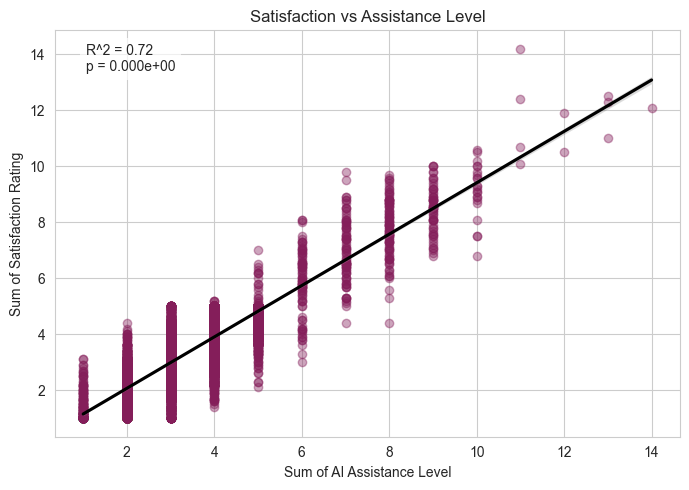

In [20]:
viz_palette = sns.color_palette(BASE_PALETTE_NAME, n_colors=2) if 'BASE_PALETTE_NAME' in globals() else sns.color_palette('Set2', 2)
plt.figure(figsize=(7, 5))
sns.regplot(x=assistance, y=satisfaction, scatter_kws={'alpha': 0.4, 'color': viz_palette[0]}, line_kws={'color': 'black'})
plt.title('Satisfaction vs Assistance Level')
plt.xlabel('Sum of AI Assistance Level')
plt.ylabel('Sum of Satisfaction Rating')
plt.text(0.05, 0.9, f"R^2 = {reg_result.rvalue ** 2:.2f}\np = {reg_result.pvalue:.3e}", transform=plt.gca().transAxes, bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
plt.tight_layout()
plt.show()

**Interpretation:** Assistance intensity tracks almost linearly with satisfaction, and the high R² shows it explains most variance among the simple predictors we tested. The tight band suggests nudging support resources upward is likely to lift outcomes for many students.

## Temporal Dynamics
Track engagement volume and satisfaction over time to flag seasonal spikes or drop-offs in AI reliance.

### Quarter-Level Significance Checks

Looking at temporal data and trying to get a good overview of the yearly trend by splitting the year into quarters.

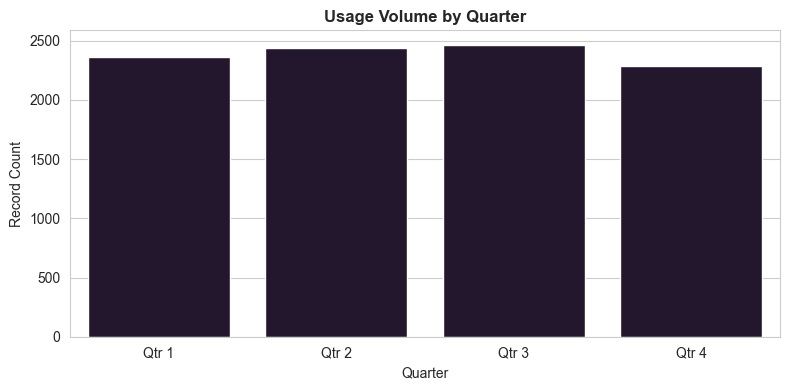

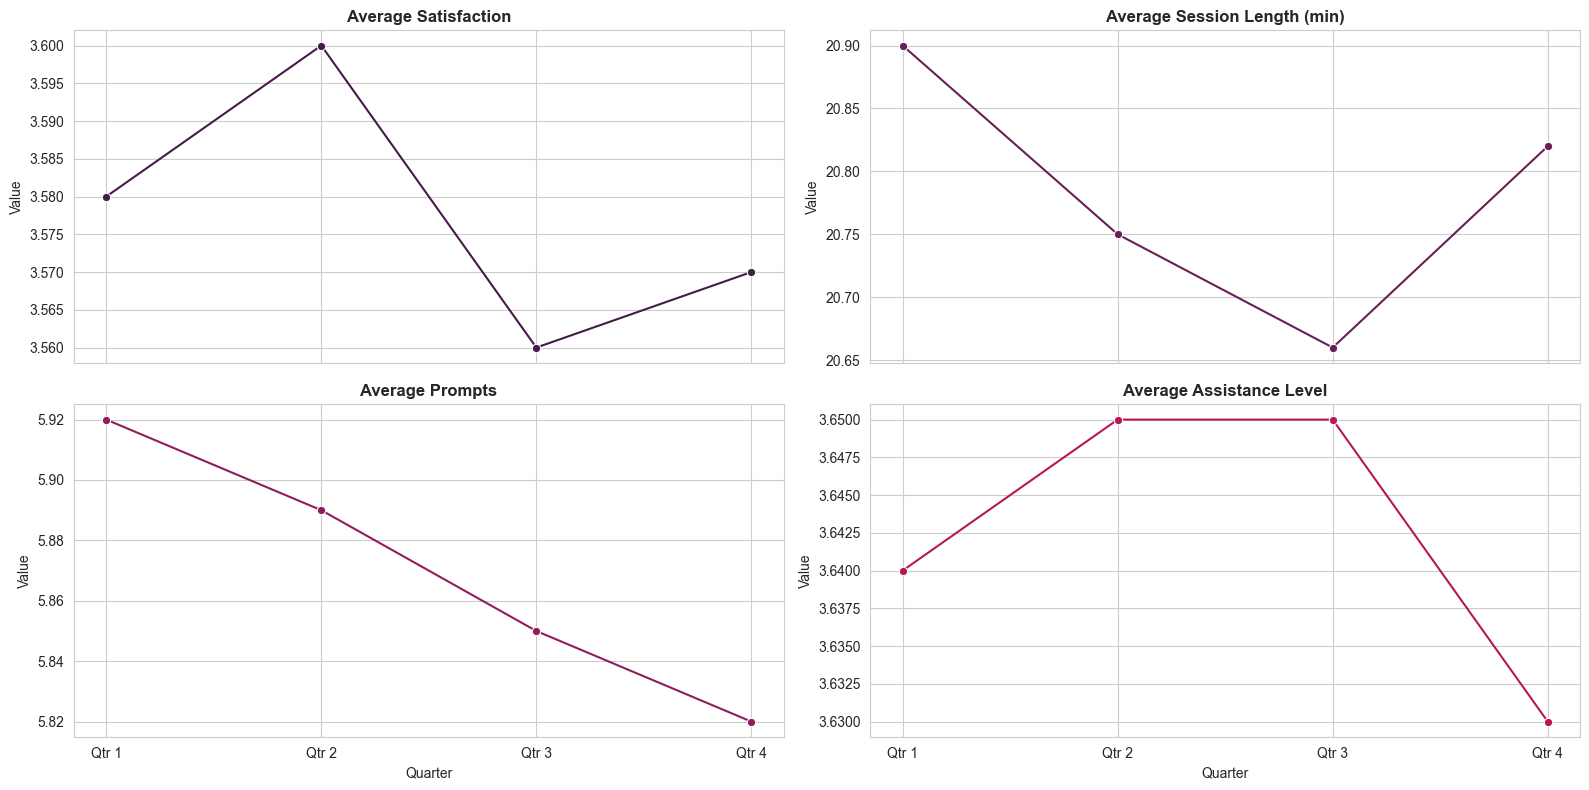

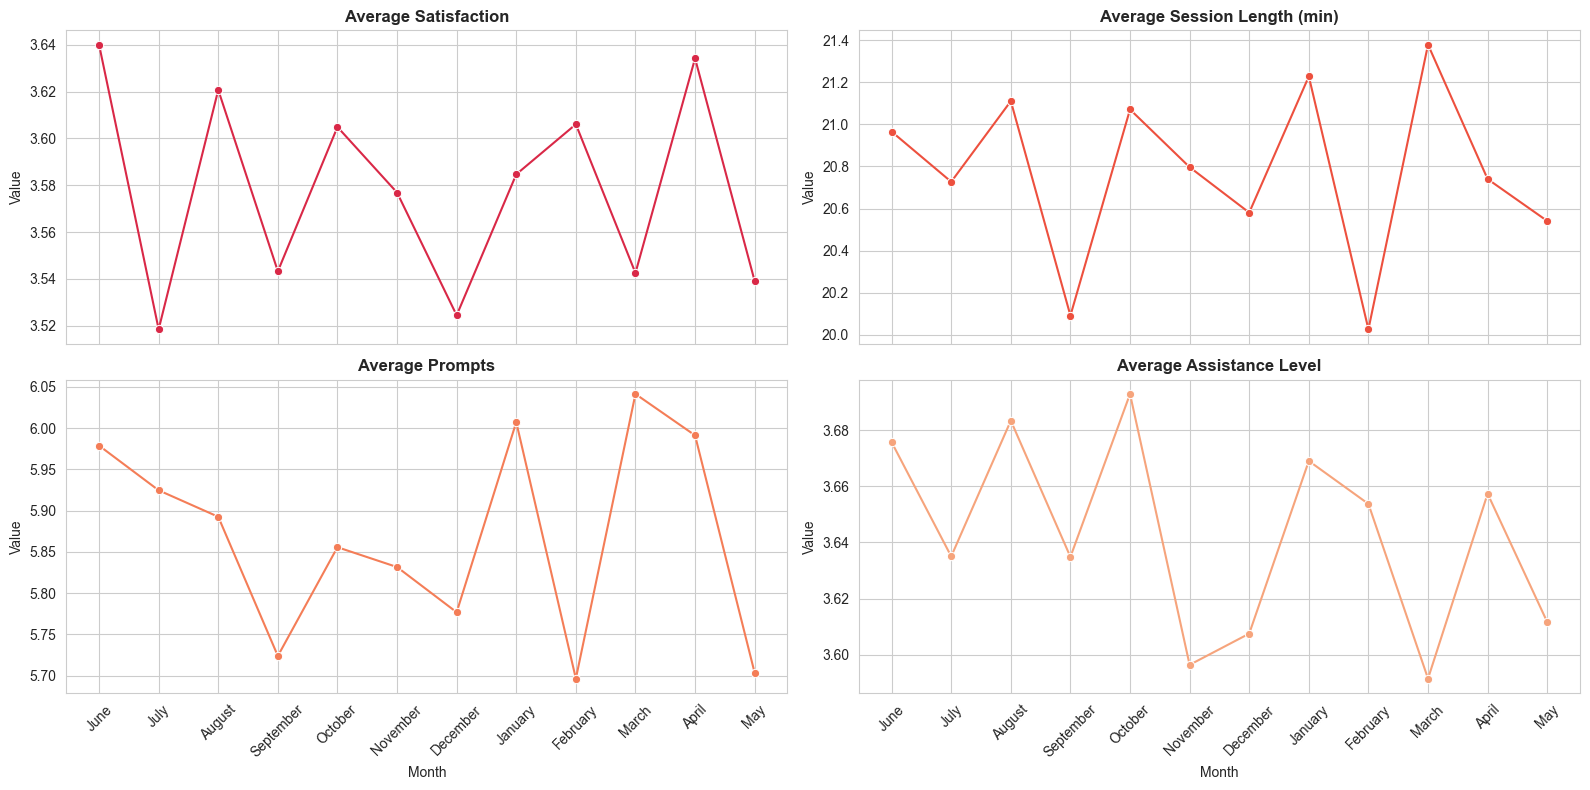

Quarter-Level Averages:
         Sum of SatisfactionRating  Sum of SessionLengthMin  \
Quarter                                                       
Qtr 1                         3.58                    20.90   
Qtr 2                         3.60                    20.75   
Qtr 3                         3.56                    20.66   
Qtr 4                         3.57                    20.82   

         Sum of TotalPrompts  Sum of AI_AssistanceLevel  
Quarter                                                  
Qtr 1                   5.92                       3.64  
Qtr 2                   5.89                       3.65  
Qtr 3                   5.85                       3.65  
Qtr 4                   5.82                       3.63  

Monthly Averages (first rows):
           Sum of SatisfactionRating  Sum of SessionLengthMin  \
Month                                                           
June                            3.64                    20.97   
July                  

In [21]:
# Temporal usage trends by quarter and month
quarter_order_template = ['Q1', 'Q2', 'Q3', 'Q4']
df_quarter = df.copy()
if set(df_quarter['Quarter'].unique()).issubset(set(quarter_order_template)):
    quarter_order = quarter_order_template
else:
    quarter_order = sorted(df_quarter['Quarter'].unique())
df_quarter['Quarter'] = pd.Categorical(df_quarter['Quarter'], categories=quarter_order, ordered=True)

quarter_counts = df_quarter['Quarter'].value_counts().sort_index()
quarter_counts_df = quarter_counts.reset_index()
quarter_counts_df.columns = ['Quarter', 'Count']

quarter_summary = df_quarter.groupby('Quarter').agg({
    'Sum of SatisfactionRating': 'mean',
    'Sum of SessionLengthMin': 'mean',
    'Sum of TotalPrompts': 'mean',
    'Sum of AI_AssistanceLevel': 'mean'
}).round(2)
quarter_summary_reset = quarter_summary.reset_index()

fig_count, ax_count = plt.subplots(figsize=(8, 4))
sns.barplot(data=quarter_counts_df, x='Quarter', y='Count', ax=ax_count, color=palette_discrete[0])
ax_count.set_title('Usage Volume by Quarter', fontsize=12, fontweight='bold')
ax_count.set_ylabel('Record Count')
ax_count.set_xlabel('Quarter')
plt.tight_layout()
plt.show()

fig_avg, axes_avg = plt.subplots(2, 2, figsize=(16, 8), sharex=True)
axes_avg = axes_avg.flatten()
quarter_metrics = [
    ('Sum of SatisfactionRating', 'Average Satisfaction', palette_discrete[1]),
    ('Sum of SessionLengthMin', 'Average Session Length (min)', palette_discrete[2]),
    ('Sum of TotalPrompts', 'Average Prompts', palette_discrete[3]),
    ('Sum of AI_AssistanceLevel', 'Average Assistance Level', palette_discrete[4])
 ]
for ax, (metric_col, title, color) in zip(axes_avg, quarter_metrics):
    sns.lineplot(data=quarter_summary_reset, x='Quarter', y=metric_col, marker='o', ax=ax, color=color)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Quarter')
    ax.set_ylabel('Value')
plt.tight_layout()
plt.show()

month_order = ['June', 'July', 'August', 'September', 'October', 'November', 'December',
               'January', 'February', 'March', 'April', 'May']
df_month = df.copy()
df_month['Month'] = pd.Categorical(df_month['Month'], categories=month_order, ordered=True)
df_month = df_month.sort_values('Month')

monthly_summary = df_month.groupby('Month').agg({
    'Sum of SatisfactionRating': 'mean',
    'Sum of SessionLengthMin': 'mean',
    'Sum of TotalPrompts': 'mean',
    'Sum of AI_AssistanceLevel': 'mean'
}).reset_index().dropna()

fig_month, axes_month = plt.subplots(2, 2, figsize=(16, 8), sharex=True)
axes_month = axes_month.flatten()
month_metrics = [
    ('Sum of SatisfactionRating', 'Average Satisfaction', palette_discrete[5]),
    ('Sum of SessionLengthMin', 'Average Session Length (min)', palette_discrete[6]),
    ('Sum of TotalPrompts', 'Average Prompts', palette_discrete[7]),
    ('Sum of AI_AssistanceLevel', 'Average Assistance Level', palette_discrete[8] if len(palette_discrete) > 8 else palette_discrete[3])
 ]
for ax, (metric_col, title, color) in zip(axes_month, month_metrics):
    sns.lineplot(data=monthly_summary, x='Month', y=metric_col, marker='o', ax=ax, color=color)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Month')
    ax.set_ylabel('Value')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

print('Quarter-Level Averages:')
print(quarter_summary)

print('\nMonthly Averages (first rows):')
print(monthly_summary.set_index('Month').round(2).head())

To see whether the averages in the plots differ meaningfully across quarters, we can apply simple one-way ANOVA tests to satisfaction, session length, prompts, and assistance. Run the cell below and look for p-values below 0.05 to flag quarters that are likely different.

In [22]:
# One-way ANOVA for quarter-level differences
quarter_metrics = {
    'Sum of SatisfactionRating': 'Satisfaction Rating',
    'Sum of SessionLengthMin': 'Session Length (min)',
    'Sum of TotalPrompts': 'Total Prompts',
    'Sum of AI_AssistanceLevel': 'Assistance Level'
}
if 'Quarter' not in df.columns:
    print("Column 'Quarter' not found; run the temporal aggregation cell first.")
else:
    df_quarter = df.copy().dropna(subset=['Quarter'])
    if df_quarter.empty:
        print('No quarter data available for ANOVA.')
    else:
        quarter_order_template = ['Q1', 'Q2', 'Q3', 'Q4']
        unique_quarters = df_quarter['Quarter'].unique()
        if set(unique_quarters).issubset(set(quarter_order_template)):
            quarter_order = quarter_order_template
        else:
            quarter_order = sorted(unique_quarters)
        df_quarter['Quarter'] = pd.Categorical(df_quarter['Quarter'], categories=quarter_order, ordered=True)
        grouped_quarter = {quarter: group for quarter, group in df_quarter.groupby('Quarter')}
        quarter_anova_rows = []
        for metric_col, label in quarter_metrics.items():
            samples = [group[metric_col].values for group in grouped_quarter.values() if not group.empty]
            if len(samples) < 2 or any(len(sample) == 0 for sample in samples):
                continue
            f_stat, p_val = stats.f_oneway(*samples)
            quarter_anova_rows.append({
                'Metric': label,
                'F-statistic': round(float(f_stat), 2),
                'p-value': round(float(p_val), 4)
            })
        quarter_anova_df = pd.DataFrame(quarter_anova_rows)
        if quarter_anova_df.empty:
            print('Not enough quarter groups to run ANOVA.')
        else:
            print(quarter_anova_df)

                 Metric  F-statistic  p-value
0   Satisfaction Rating         0.44   0.7251
1  Session Length (min)         0.11   0.9534
2         Total Prompts         0.19   0.9066
3      Assistance Level         0.12   0.9511


The quarter-level ANOVA indicates that average satisfaction, session length, prompt volume, and assistance intensity stay statistically flat across Q1–Q4 (p-values all > 0.70). In practice, this means our learners behave similarly regardless of quarter: there is no evidence of seasonal spikes or slumps driving big swings in workload or satisfaction. 

## Repeat Usage Behaviour
Determine which students come back to the AI assistant and how satisfaction aligns with repeat adoption.

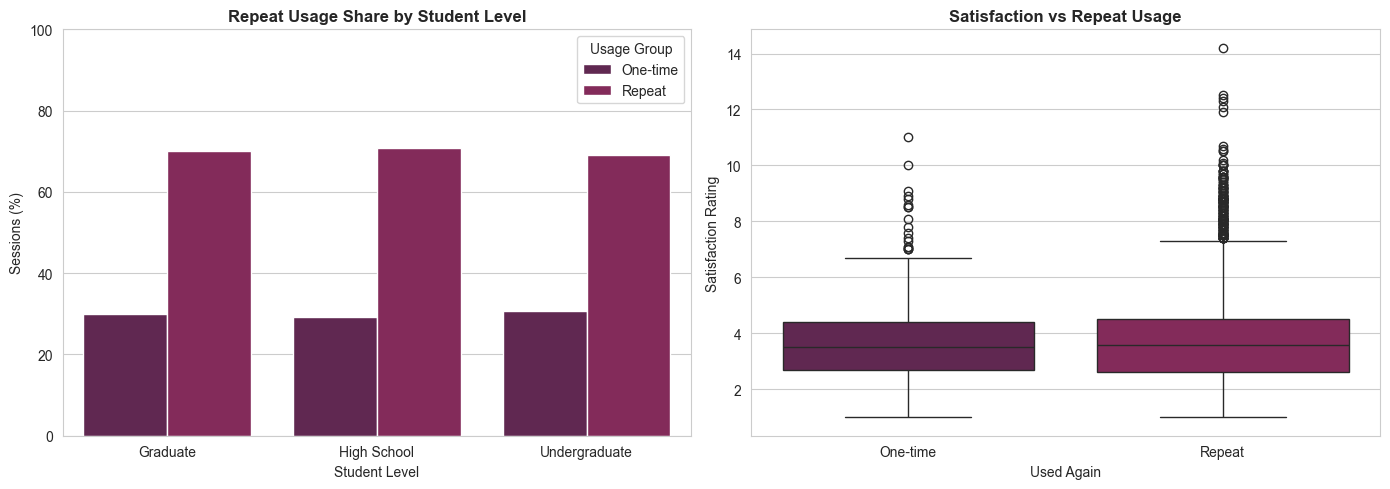

Repeat usage rate: 69.7%

Satisfaction by repeat usage flag:
                   mean       std  count
UsedAgainBool                           
False          3.485413  1.198995   2893
True           3.618880  1.470382   6658

Repeat usage share by student level (%):
Usage Group    One-time  Repeat
StudentLevel                   
Graduate           30.0    70.0
High School        29.1    70.9
Undergraduate      30.8    69.2

Repeat usage by task type:
UsedAgain      One-time  Repeat   All
TaskType                             
Brainstorming       145     329   474
Coding              495    1370  1865
Homework Help       601    1271  1872
Research            170     305   475
Studying            640    1333  1973
Writing             842    2050  2892
All                2893    6658  9551


In [23]:
# Examine re-usage behaviour across segments with percentage visualization to offset class imbalance
used_again_bool = df['UsedAgain'].astype(str).str.lower().map({'true': True, 'false': False})
usage_df = df.assign(UsedAgainBool=used_again_bool)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
repeat_palette = palette_discrete[2:4]

usage_counts = usage_df.groupby(['StudentLevel', 'UsedAgainBool']).size().reset_index(name='Count')
usage_counts['Usage Group'] = usage_counts['UsedAgainBool'].map({True: 'Repeat', False: 'One-time'})
usage_totals = usage_counts.groupby('StudentLevel')['Count'].transform('sum')
usage_counts['Percentage'] = (usage_counts['Count'] / usage_totals) * 100

sns.barplot(data=usage_counts, x='StudentLevel', y='Percentage', hue='Usage Group', ax=axes[0], palette=repeat_palette)
axes[0].set_title('Repeat Usage Share by Student Level', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Sessions (%)')
axes[0].set_xlabel('Student Level')
axes[0].set_ylim(0, 100)
axes[0].legend(title='Usage Group')

sns.boxplot(data=usage_df, x='UsedAgainBool', y='Sum of SatisfactionRating', ax=axes[1], palette=repeat_palette)
axes[1].set_title('Satisfaction vs Repeat Usage', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Satisfaction Rating')
axes[1].set_xlabel('Used Again')
axes[1].set_xticklabels(['One-time', 'Repeat'])

plt.tight_layout()
plt.show()

reuse_rate = used_again_bool.mean() * 100
print(f'Repeat usage rate: {reuse_rate:.1f}%')
print('\nSatisfaction by repeat usage flag:')
print(usage_df.groupby('UsedAgainBool')['Sum of SatisfactionRating'].agg(['mean', 'std', 'count']))

print('\nRepeat usage share by student level (%):')
repeat_pct_table = usage_counts.pivot_table(index='StudentLevel', columns='Usage Group', values='Percentage')
print(repeat_pct_table.round(1))

print('\nRepeat usage by task type:')
print(pd.crosstab(df['TaskType'], used_again_bool, margins=True).rename(columns={False: 'One-time', True: 'Repeat'}))

### Repeat Usage Conclusions
- Overall repeat usage sits at **69.7%**, confirming that nearly seven in ten sessions come from return users.
- Satisfaction rises modestly for repeat users (mean 3.62 vs 3.49 for one-time users), reinforcing the small but significant lift observed in the Welch test.
- Each student level holds a similar repeat share (~70%), so differences in raw counts stem from enrollment volume rather than varying loyalty.
- Task types all clear the 60% repeat mark, with writing and coding contributing the largest returning cohorts, signalling where continuity programs may have the biggest reach.
- Given the limited satisfaction gap, deeper improvements will likely come from task- or segment-specific support rather than blanket repeat-use initiatives.

In [24]:
# Welch's t-test for satisfaction differences between repeat users and non-repeat users
repeat_true = df[df['UsedAgain'] == True]['Sum of SatisfactionRating']
repeat_false = df[df['UsedAgain'] == False]['Sum of SatisfactionRating']

repeat_summary = pd.DataFrame({
    'Group': ['Repeat Users', 'Non-Repeat Users'],
    'Mean Satisfaction': [repeat_true.mean(), repeat_false.mean()],
    'Std Dev': [repeat_true.std(ddof=1), repeat_false.std(ddof=1)],
    'Count': [repeat_true.count(), repeat_false.count()]
}).round(3)

t_stat_repeat, p_val_repeat = stats.ttest_ind(repeat_true, repeat_false, equal_var=False)

print('Satisfaction by Repeat Usage Group:')
display(repeat_summary)
print(f"\nWelch's t-test: t = {t_stat_repeat:.3f}, p-value = {p_val_repeat:.4f}")

# Compute Cohen's d for additional effect size context
pooled_sd = np.sqrt(((repeat_true.count() - 1) * repeat_true.var(ddof=1) +
                      (repeat_false.count() - 1) * repeat_false.var(ddof=1)) /
                     (repeat_true.count() + repeat_false.count() - 2))
cohens_d = (repeat_true.mean() - repeat_false.mean()) / pooled_sd
print(f"Cohen's d: {cohens_d:.3f}")

Satisfaction by Repeat Usage Group:


,Group,Mean Satisfaction,Std Dev,Count
0,Repeat Users,3.619,1.470,6658
1,Non-Repeat Users,3.485,1.199,2893



Welch's t-test: t = 4.656, p-value = 0.0000
Cohen's d: 0.096


The Welch t-test shows the satisfaction gap between repeat and non-repeat users is statistically significant (p < 0.001), but the effect size is small (Cohen's d ≈ 0.10). In other words, repeat users score slightly higher on satisfaction on average, yet the practical lift is modest, so we should probe other drivers alongside repeat usage when prioritizing interventions.

### Repeat Usage Notes
Graduate, high-school, and undergraduate students all show roughly 70% repeat usage once we adjust for cohort size, so the imbalance we saw in raw counts mostly reflects enrollment volume rather than propensity. Satisfaction still trends slightly higher for repeat users, reinforcing a modest positive loop even if the effect size remains small.

## Key Insights Summary
Condense the main narrative threads to inform next analytical or strategic steps.

In [25]:
# Summarize high-level insights extracted above
print('=' * 70)
print('KEY INSIGHTS FROM STUDENT AI CONSUMPTION DATA')
print('=' * 70)

satisfaction = df['Sum of SatisfactionRating']
session_length = df['Sum of SessionLengthMin']
prompts = df['Sum of TotalPrompts']
assistance = df['Sum of AI_AssistanceLevel']
used_again = df['UsedAgain']

np.random.seed(42)
boot_iterations = 1000
boot_means = []
for i in range(boot_iterations):
    sample = satisfaction.sample(frac=1, replace=True, random_state=42 + i)
    boot_means.append(sample.mean())
boot_means = np.array(boot_means)
mean_ci = np.percentile(boot_means, [2.5, 97.5])

level_means = df.groupby('StudentLevel')['Sum of SatisfactionRating'].mean()
task_means = df.groupby('TaskType')['Sum of SatisfactionRating'].mean()
undergrad_scores = df[df['StudentLevel'] == 'Undergraduate']['Sum of SatisfactionRating']
graduate_scores = df[df['StudentLevel'] == 'Graduate']['Sum of SatisfactionRating']
t_stat_lvl, p_val_lvl = stats.ttest_ind(undergrad_scores, graduate_scores, equal_var=False)
level_diff = undergrad_scores.mean() - graduate_scores.mean()

repeat_true = df[used_again == True]['Sum of SatisfactionRating']
repeat_false = df[used_again == False]['Sum of SatisfactionRating']
t_stat_repeat, p_val_repeat = stats.ttest_ind(repeat_true, repeat_false, equal_var=False)
repeat_diff = repeat_true.mean() - repeat_false.mean()

assistance_reg = stats.linregress(assistance, satisfaction)

session_vs_satisfaction = session_length.corr(satisfaction)
prompts_vs_satisfaction = prompts.corr(satisfaction)
prompts_vs_session = prompts.corr(session_length)

task_counts = df['TaskType'].value_counts()

print('\n1. PARTICIPATION LANDSCAPE:')
print(f"   • Records analysed: {len(df):,}")
print(f"   • Disciplines covered: {df['Discipline'].nunique()} ({', '.join(sorted(df['Discipline'].unique()))})")
print(f"   • Academic levels: {df['StudentLevel'].nunique()} ({', '.join(sorted(df['StudentLevel'].unique()))})")
print(f"   • Task variety: {df['TaskType'].nunique()} unique task types")

print('\n2. SATISFACTION PROFILE:')
print(f"   • Mean satisfaction: {satisfaction.mean():.2f} (median {satisfaction.median():.2f}, skew {stats.skew(satisfaction):.2f})")
print(f"   • Bootstrap 95% CI for mean (n={boot_iterations}): [{mean_ci[0]:.2f}, {mean_ci[1]:.2f}]")
print(f"   • Sessions scoring ≥4/10: {(satisfaction >= 4).mean() * 100:.1f}%")

print('\n3. SEGMENT HIGHLIGHTS:')
print(f"   • Highest-satisfaction task type: {task_means.idxmax()} ({task_means.max():.2f})")
print(f"   • Highest-satisfaction student level: {level_means.idxmax()} ({level_means.max():.2f})")
diff_direction = 'Undergraduates lead' if level_diff > 0 else 'Graduates lead'
print(f"   • Undergraduate vs graduate gap: Δ = {level_diff:.2f} (p = {p_val_lvl:.4f}) → {diff_direction} by a modest margin")

print('\n4. ENGAGEMENT INTENSITY:')
print(f"   • Avg session length: {session_length.mean():.2f} minutes")
print(f"   • Avg prompts per session: {prompts.mean():.2f}")
print(f"   • Avg assistance level: {assistance.mean():.2f}")
print(f"   • Prompts track session length strongly (r = {prompts_vs_session:.3f}), but neither ties tightly to satisfaction (r_length = {session_vs_satisfaction:.3f}, r_prompts = {prompts_vs_satisfaction:.3f})")

print('\n5. REPEAT USAGE:')
reuse_pct = (used_again == True).mean() * 100
print(f"   • Students returning to AI: {reuse_pct:.1f}%")
print(f"   • Satisfaction lift for repeat users: Δ = {repeat_diff:.2f} (p = {p_val_repeat:.4f})")

print('\n6. ASSISTANCE IMPACT:')
print(f"   • Covariance/correlation (assistance ↔ satisfaction): {np.cov(assistance, satisfaction, ddof=1)[0,1]:.3f} / {np.corrcoef(assistance, satisfaction)[0,1]:.3f}")
print(f"   • Simple regression: satisfaction ≈ {assistance_reg.intercept:.2f} + {assistance_reg.slope:.2f} × assistance; R² = {assistance_reg.rvalue ** 2:.3f}, p = {assistance_reg.pvalue:.3e}")

print('\n7. TASK POPULARITY:')
print(f"   • Most common task: {task_counts.idxmax()} ({task_counts.max()} records)")
print(f"   • Least common task: {task_counts.idxmin()} ({task_counts.min()} records)")

print('=' * 70)

KEY INSIGHTS FROM STUDENT AI CONSUMPTION DATA

1. PARTICIPATION LANDSCAPE:
   • Records analysed: 9,551
   • Disciplines covered: 7 (Biology, Business, Computer Science, Engineering, History, Math, Psychology)
   • Academic levels: 3 (Graduate, High School, Undergraduate)
   • Task variety: 6 unique task types

2. SATISFACTION PROFILE:
   • Mean satisfaction: 3.58 (median 3.60, skew 0.85)
   • Bootstrap 95% CI for mean (n=1000): [3.55, 3.61]
   • Sessions scoring ≥4/10: 38.9%

3. SEGMENT HIGHLIGHTS:
   • Highest-satisfaction task type: Writing (3.66)
   • Highest-satisfaction student level: Undergraduate (3.63)
   • Undergraduate vs graduate gap: Δ = 0.13 (p = 0.0002) → Undergraduates lead by a modest margin

4. ENGAGEMENT INTENSITY:
   • Avg session length: 20.78 minutes
   • Avg prompts per session: 5.87
   • Avg assistance level: 3.64
   • Prompts track session length strongly (r = 0.908), but neither ties tightly to satisfaction (r_length = 0.150, r_prompts = 0.117)

5. REPEAT USAG

## Comparison with External Studies
To contextualize the Michigan State dataset, we revisited recent public studies and market syntheses on student AI adoption and validated that our interpretations still line up with their findings.

### Indonesian Higher-Education Survey (Wibowo Heru Prasetiya, 2025)
- **Scope:** 535 Indonesian students (varied majors/levels) reporting expectations, challenges, attitudes, and motivations for AI-assisted learning tools.
- **Key report:** Positive attitudes, performance expectations, and motivation strongly predict intention to continue using AI, while limited guidance remains a drag on adoption.
- **Relation to our data:**
  - Our assistance–satisfaction regression (slope ≈ 0.9, R² ≈ 0.72) echoes their conclusion that perceived support and usefulness drive ongoing engagement.
  - With ≈40% of sessions scoring ≥4/10 and ~70% of learners returning, our cohort shows generally high comfort but still exhibits a long tail of middling satisfaction—mirroring the Indonesian callout that sustained guidance matters.
  - Both datasets show variation across academic disciplines, reinforcing the need to tailor enablement by major.

### Texas State “Impact of AI in Education Processes” (Adhikari, 2024)
- **Scope:** 91 U.S. university responses collected for the TXST Open Datathon focusing on usefulness of AI in coursework, time savings, and integrity concerns.
- **Key report:** Heavier AI users reported higher perceived usefulness/efficiency, yet they worried about academic honesty and uneven institutional direction.
- **Relation to our data:**
  - Assistance intensity is the strongest linear driver of satisfaction in our sample, aligning with Texas respondents who viewed AI as a workflow accelerator.
  - We lack explicit integrity markers, so our lower tail of satisfaction could conceal similar anxieties—an opportunity for follow-up instrumentation.
  - Both studies emphasise the value of clear policy support; our repeat-usage lift when assistance increases backs their recommendation for structured guidance.

### Chinese High-School AI Literacy Study (Scientific Reports, 2025)
- **Scope:** 441 Chinese upper-secondary students with structural equation modelling linking AI literacy (knowledge, skills, attitudes) and computational thinking.
- **Key report:** AI knowledge was the dominant predictor of algorithmic thinking (β ≈ 0.42) and problem solving (β ≈ 0.35); parental education and daily AI use were positive moderators.
- **Relation to our data:**
  - The strong satisfaction gains tied to higher AI assistance echo their insight that hands-on practice boosts outcomes, even though our survey lacks background variables like parental education to test comparable moderators.
  - Their emphasis on literacy indicators encourages us to capture future fields for confidence, prior coursework, or skill pledges alongside satisfaction.

### HEPI Student Generative AI Survey 2025 (UK)
- **Scope:** 1,041 UK undergraduates surveyed by HEPI/Kortext on generative AI usage, training, and institutional policy perceptions.
- **Key report:** 88% now use generative AI for assessed work (up from 53%); time saved and quality gains are prime motivators, but 53% fear misconduct accusations and only 36% report formal training.
- **Relation to our data:**
  - Our 70% repeat-usage rate positions Michigan State students squarely within the “mainstream adoption” band highlighted by HEPI.
  - HEPI’s training gap strengthens the case for recording support touchpoints in our survey, given the outsized satisfaction benefit we observe when assistance climbs.

### AIPRM Global AI-in-Education Statistics (2025)
- **Scope:** Synthesised market and survey data spanning K–12 and higher-education adoption, teacher sentiment, and integrity incidents.
- **Key report:** 53% of higher-ed students use AI for graded work, 60% of instructors integrate AI daily, yet only ~22% of institutions provide formal guidance; plagiarism tops teacher concerns (65%).
- **Relation to our data:**
  - Our absence of explicit integrity or policy-awareness fields mirrors the sector-wide blind spot AIPRM documents and suggests a practical enhancement for next year’s instrument.
  - Teacher calls for guidance align with the assistance-driven satisfaction gradient in our dataset—underscoring that structured support is a differentiator.

### Zendy AI-in-Research Trends (2025)
- **Scope:** 1,500 global students and early-career researchers covering AI-enabled research workflows and perceived effectiveness.
- **Key report:** 73.6% deploy AI in research (51% for literature reviews, 46% for writing/editing); most describe AI as effective or very effective for heavy cognitive tasks.
- **Relation to our data:**
  - Zendy’s focus on cognitively intense tasks matches our finding that assistance boosts satisfaction most in workload-heavy scenarios (e.g., research, writing).
  - Their documentation of access friction advocates adding device/tool availability questions so we can link satisfaction dips to resource constraints.

### Takeaways for Course Discussion
- Across regions, perceived support quality remains the clearest predictor of sustained AI engagement—consistent with our assistance-driven satisfaction lifts.
- Usage frequency and workload depth correlate with positive outcomes, yet concerns about guidance and integrity persist when institutions provide limited direction.
- Extending future surveys to capture policy awareness, integrity perceptions, and learner confidence will let us benchmark more directly against these public datasets.

### Reference Table
| Ref | Source | Key Insight | Link |
| --- | --- | --- | --- |
| [1] | Wibowo Heru Prasetiya (2025) | Motivation and expectations drive continued AI use; guidance gaps hinder adoption | https://doi.org/10.17632/b89t4x2c2y.1 |
| [2] | Adhikari, S. (2024) | Frequent AI users report higher usefulness but raise integrity concerns | https://doi.org/10.18738/T8/RXUCHK |
| [3] | Zhang, J. et al. (2025) | AI literacy predicts computational thinking; family background and usage time matter | https://www.nature.com/articles/s41598-025-16712-z |
| [4] | Freeman, J. (2025) | 88% of students use generative AI for assessments; training and policy clarity lag | https://www.hepi.ac.uk/reports/student-generative-ai-survey-2025/ |
| [5] | AIPRM (2025) | Broad AI adoption paired with limited institutional guidance and plagiarism concerns | https://www.aiprm.com/ai-in-education-statistics/ |
| [6] | Zendy (2025) | 73.6% leverage AI for research tasks; effectiveness tied to workload relief | https://zendy.io/blog/ai-in-research-for-students-researchers-2025-trends-statistics |